# DiT Next-Frame Prediction Evaluation

Loads a trained DiT checkpoint, runs `rollout()` on a DROID val sample with GT actions,
and visualizes predicted vs GT next frames.

Two visualization modes:
- **SH→RGB**: Direct DC-band SH extraction (`rgb = 0.5 + C0 * sh`)
- **Rendered**: Full Gaussian Splatting render via `diff-gaussian-rasterization`

In [1]:
import os, sys
sys.path.insert(0, os.path.expandvars("$GWM_PATH"))
import torch, numpy as np, matplotlib.pyplot as plt
from hydra import compose, initialize
from hydra.core.global_hydra import GlobalHydra

In [2]:
GWM_PATH = os.environ["GWM_PATH"]

GlobalHydra.instance().clear()
with initialize(config_path="../configs", version_base=None):
    cfg = compose(config_name="train_gwm", overrides=[
        "world_model.observation.use_gs=true",
        "world_model.reward.use_reward_model=false",
        "world_model.vae.use_vae=false",
        f"dataset.data_path={GWM_PATH}/data/",
    ])

print("Config loaded. context_length:", cfg.world_model.context_length)

Config loaded. context_length: 2


In [3]:
from gaussianwm.gwm_predictor import GaussianPredictor

CKPT = f"{GWM_PATH}/logs/gwm/checkpoints/model_latest.pt"
model = GaussianPredictor(cfg.world_model).cuda()
state_dict = torch.load(CKPT, map_location="cuda")
model.model.load_state_dict(state_dict)
model.eval()
print(f"Loaded DiT from {CKPT}")

/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-27 14:24:38.277601: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-27 14:24:38.277631: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-27 14:24:38.278443: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-27 14:24:38.283077: I tensorflow/core/platform/cpu_feature_guard.cc:182] This

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [on]


/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(

🔥🔥🔥 Splatt3r Model loaded from /home/frankcholula/Workspace/gaussianwm/third_party/splatt3r/checkpoints/splatt3r_v1.0/epoch=19-step=1200.ckpt
[Model] Trainable parameters: 33.205088M
[Model] Total parameters: 33.598304M


/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


loaded pretrained LPIPS loss from /home/frankcholula/Workspace/gaussianwm/ckpt/lpips/vgg.pth
Loaded DiT from /home/frankcholula/Workspace/gaussianwm/logs/gwm/checkpoints/model_latest.pt


/home/frankcholula/Workspace/gaussianwm/gaussianwm/vq_model/lpips.py:74: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(ckpt, map_location=tor

In [4]:
import tensorflow_datasets as tfds
import tensorflow as tf
import glob, json
from gaussianwm.processor.datasets import euler_to_rmat, mat_to_rot6d
from PIL import Image as PILImage

GWM_PATH = os.environ["GWM_PATH"]

# Load episode 0 directly — no RLDS pipeline, no threads, no shuffle buffer
ds    = tfds.load("droid_100", data_dir=f"{GWM_PATH}/data/", split="train", with_info=False)
ep    = next(iter(ds))
steps = list(ep["steps"])
print(f"Episode 0: {len(steps)} frames  ({len(steps)/15:.1f}s @ 15Hz)")

# Extract raw images (resize to 128×128) and action components
frames, raw_cart, raw_grip = [], [], []
for step in steps:
    img = PILImage.fromarray(step["observation"]["exterior_image_1_left"].numpy())
    frames.append(np.array(img.resize((128, 128), PILImage.BILINEAR)))
    raw_cart.append(step["action_dict"]["cartesian_position"].numpy())
    raw_grip.append(step["action_dict"]["gripper_position"].numpy())

# Build 10-dim action: xyz(3) + rot6d(6) + gripper(1)  — same as droid_dataset_transform
cart_tf = tf.constant(np.stack(raw_cart), dtype=tf.float32)
grip_tf = tf.constant(np.stack(raw_grip), dtype=tf.float32)
actions_10d = tf.concat([
    cart_tf[:, :3],
    mat_to_rot6d(euler_to_rmat(cart_tf[:, 3:6])),
    grip_tf,
], axis=-1).numpy().astype(np.float32)   # [T, 10]

# Bounds normalization (q01/q99) — same as training pipeline
stats_file = sorted(glob.glob(f"{GWM_PATH}/data/droid_100/1.0.0/dataset_statistics_*.json"))[0]
with open(stats_file) as f:
    stats = json.load(f)
q01 = np.array(stats["action"]["q01"], dtype=np.float32)
q99 = np.array(stats["action"]["q99"], dtype=np.float32)
actions_norm = 2 * (actions_10d - q01) / (q99 - q01 + 1e-8) - 1
actions_norm[:, 9] = actions_10d[:, 9]   # gripper dim: not normalized

# Match pipeline shift: trajectory["action"][1:]
actions_norm = actions_norm[1:]

obs    = torch.from_numpy(np.stack(frames))        # [T,   128, 128, 3] uint8
action = torch.from_numpy(actions_norm)            # [T-1, 10]  float32
reward = torch.zeros(len(steps) - 1)

print(f"obs: {obs.shape},  action: {action.shape}")

2026-02-27 14:24:54.529160: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-27 14:24:54.531076: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Episode 0: 166 frames  (11.1s @ 15Hz)
obs: torch.Size([166, 128, 128, 3]),  action: torch.Size([165, 10])


In [19]:
import imageio
from PIL import Image, ImageDraw

# ── Save ground truth frames as gt.gif ────────────────────────────────────────
# Run this cell to preview the selected clip BEFORE the expensive DiT rollout.
# Each frame is labelled with its timestamp in seconds.

GT_GIF_FPS   = 5     # slow playback so motion is easy to see
GT_GIF_SCALE = 3     # 3× upscale: 128px → 384px
GT_GIF_OUT   = "gt.gif"

T = obs.shape[0]
gt_frames = []

for t in range(T):
    frame_u8 = obs[t].numpy()   # [H, W, 3] uint8

    img = Image.fromarray(frame_u8).resize(
        (frame_u8.shape[1] * GT_GIF_SCALE, frame_u8.shape[0] * GT_GIF_SCALE),
        Image.NEAREST,
    )
    draw = ImageDraw.Draw(img)
    draw.rectangle([0, 0, img.width, 16], fill=(0, 0, 0))
    draw.text((4, 2), f"GT  frame={t}  t={t/15:.2f}s", fill=(255, 255, 255))
    gt_frames.append(np.array(img))

imageio.mimsave(GT_GIF_OUT, gt_frames, fps=GT_GIF_FPS, loop=0)
print(f"Saved {GT_GIF_OUT}  —  {T} frames @ {GT_GIF_FPS}fps  "
      f"({T/GT_GIF_FPS:.1f}s playback,  {T/15:.1f}s real time)")

Saved gt.gif  —  166 frames @ 5fps  (33.2s playback,  11.1s real time)


In [5]:
CONTEXT     = cfg.world_model.context_length   # 2
MAX_ROLLOUT = 8    # match training horizon (rollout_horizon=8 in train_gwm.yaml)
START_FRAME = 25   # start context here; movement begins ~frame 20

HORIZON = min(
    obs.shape[0]    - START_FRAME - CONTEXT,
    action.shape[0] - START_FRAME - CONTEXT,
    MAX_ROLLOUT,
)
print(f"obs frames: {obs.shape[0]}, action steps: {action.shape[0]}")
print(f"START_FRAME={START_FRAME}, CONTEXT={CONTEXT}, HORIZON={HORIZON}")
print(f"Predicting frames {START_FRAME+CONTEXT} – {START_FRAME+CONTEXT+HORIZON-1}  "
      f"({(START_FRAME+CONTEXT)/15:.2f}s – {(START_FRAME+CONTEXT+HORIZON-1)/15:.2f}s)")

context   = obs[START_FRAME:START_FRAME+CONTEXT].permute(0, 3, 1, 2).float()
obs_input = context.reshape(1, -1, 128, 128).cuda()

gt_actions = action[START_FRAME+CONTEXT : START_FRAME+CONTEXT+HORIZON].float().cuda()

def gt_policy(obs_t, t):
    return gt_actions[t].unsqueeze(0)

with torch.no_grad():
    rollout_obs, rollout_actions, rollout_rewards = model.rollout(
        obs_input, policy=gt_policy, horizon=HORIZON
    )
print(f"rollout_obs: {rollout_obs.shape}")
assert rollout_obs.shape == (1, HORIZON + 1, 28, 128, 128)

obs frames: 166, action steps: 165
START_FRAME=25, CONTEXT=2, HORIZON=8
Predicting frames 27 – 34  (1.80s – 2.27s)
rollout_obs: torch.Size([1, 9, 28, 128, 128])


In [6]:
# Wire up Gaussian Splatting renderer from the already-loaded Splatt3r submodule.
# regressor.py already appended these paths when GaussianPredictor was initialised,
# so the imports below should resolve immediately (modules are already in sys.modules).
from src.pixelsplat_src.cuda_splatting import render_cuda
from utils.geometry import build_covariance
from utils.geometry import normalize_intrinsics as _norm_K

H, W = 128, 128

# Standard pinhole intrinsics in pixel space: focal = image_width → ≈53° FoV
# After normalize_intrinsics: [[1, 0, 0.5], [0, 1, 0.5], [0, 0, 1]]
_K_px  = torch.tensor([[[float(W), 0., W/2.],
                          [0., float(H), H/2.],
                          [0.,      0.,    1.]]],
                        dtype=torch.float32, device="cuda")
_K_norm = _norm_K(_K_px, (H, W))           # [1, 3, 3]

# Identity camera-to-world (c2w=I): camera at origin, looking along +Z
# Gaussian means are in view1's camera frame → identity c2w renders view1's image
_C2W  = torch.eye(4, dtype=torch.float32, device="cuda").unsqueeze(0)  # [1, 4, 4]
_near = torch.tensor([0.1],   dtype=torch.float32, device="cuda")
_far  = torch.tensor([100.0], dtype=torch.float32, device="cuda")
_bg   = torch.zeros(1, 3,    dtype=torch.float32, device="cuda")


def render_gaussians(gauss_14hw: torch.Tensor) -> np.ndarray:
    """Render a [14, H, W] CUDA tensor → [H, W, 3] numpy RGB in [0, 1].

    14-dim layout (must match Splatt3r / GWM convention):
      0:3  → XYZ means  (in view1 camera frame)
      3:6  → scales     (linear, post-activation)
      6:10 → rotations  (quaternion xyzw)
     10:13 → SH DC band (3 colour channels, 1 coefficient each)
     13:14 → opacity    (sigmoid-activated, clamped to [0, 1])
    """
    N = H * W
    g = gauss_14hw.reshape(14, N).T.contiguous()   # [N, 14]

    means  = g[:, 0:3]                             # [N, 3]
    scales = g[:, 3:6]                             # [N, 3]
    rots   = g[:, 6:10]                            # [N, 4]  xyzw
    sh_dc  = g[:, 10:13]                           # [N, 3]
    opc    = g[:, 13:14].clamp(0, 1)               # [N, 1]

    covs = build_covariance(scales, rots)          # [N, 3, 3]

    rendered = render_cuda(
        _C2W,                              # [1, 4, 4]
        _K_norm,                           # [1, 3, 3]
        _near,                             # [1]
        _far,                              # [1]
        (H, W),
        _bg,                               # [1, 3]
        means.unsqueeze(0),                # [1, N, 3]
        covs.unsqueeze(0),                 # [1, N, 3, 3]
        sh_dc.unsqueeze(-1).unsqueeze(0),  # [1, N, 3, 1]  (degree-0 SH)
        opc.squeeze(-1).unsqueeze(0),      # [1, N]
    )  # → [1, 3, H, W]

    # render_cuda sets requires_grad=True internally (mean_gradients for rasterizer)
    return rendered[0].permute(1, 2, 0).clamp(0, 1).detach().cpu().numpy()  # [H, W, 3]


# ── Baseline SH→RGB helpers (no rendering) ────────────────────────────────────
C0 = 0.28209479177387814

def gauss_to_rgb(gauss_14hw: torch.Tensor) -> np.ndarray:
    """[14, H, W] → [H, W, 3] numpy via direct DC-band SH→RGB (fast baseline)."""
    sh = gauss_14hw[10:13]  # [3, H, W]
    return (0.5 + C0 * sh).clamp(0, 1).permute(1, 2, 0).detach().cpu().numpy()

def gt_frame_rgb(obs_thwc: torch.Tensor, t: int) -> np.ndarray:
    """Raw uint8 GT frame at time t → [H, W, 3] numpy in [0, 1]."""
    return obs_thwc[t].float().numpy() / 255.


print("Renderer ready  (identity c2w, focal=image_width)")
print("SH→RGB helpers ready  (gauss_to_rgb, gt_frame_rgb)")

Renderer ready  (identity c2w, focal=image_width)
SH→RGB helpers ready  (gauss_to_rgb, gt_frame_rgb)


In [7]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

psnrs_sh,     ssims_sh     = [], []
psnrs_render, ssims_render = [], []

for t in range(HORIZON):
    gt_t   = START_FRAME + CONTEXT + t
    gt_img = gt_frame_rgb(obs, gt_t)

    pred_gauss = rollout_obs[0, t+1, 14:].clone()

    pred_sh = gauss_to_rgb(pred_gauss)
    p_sh = psnr(gt_img, pred_sh, data_range=1.0)
    s_sh = ssim(gt_img, pred_sh, data_range=1.0, channel_axis=2)
    psnrs_sh.append(p_sh);  ssims_sh.append(s_sh)

    pred_rend = render_gaussians(pred_gauss)
    p_r = psnr(gt_img, pred_rend, data_range=1.0)
    s_r = ssim(gt_img, pred_rend, data_range=1.0, channel_axis=2)
    psnrs_render.append(p_r);  ssims_render.append(s_r)

    print(f"t={gt_t:2d}  SH→RGB: PSNR={p_sh:.2f} dB  SSIM={s_sh:.4f}"
          f"   |   Rendered: PSNR={p_r:.2f} dB  SSIM={s_r:.4f}")

print(f"\nMean SH→RGB  :  PSNR={np.mean(psnrs_sh):.2f} dB   SSIM={np.mean(ssims_sh):.4f}")
print(f"Mean Rendered:  PSNR={np.mean(psnrs_render):.2f} dB   SSIM={np.mean(ssims_render):.4f}")

t=27  SH→RGB: PSNR=32.75 dB  SSIM=0.9868   |   Rendered: PSNR=7.18 dB  SSIM=0.0544
t=28  SH→RGB: PSNR=29.62 dB  SSIM=0.9763   |   Rendered: PSNR=7.25 dB  SSIM=0.0524
t=29  SH→RGB: PSNR=26.84 dB  SSIM=0.9620   |   Rendered: PSNR=6.97 dB  SSIM=0.0332
t=30  SH→RGB: PSNR=25.42 dB  SSIM=0.9492   |   Rendered: PSNR=6.76 dB  SSIM=0.0135
t=31  SH→RGB: PSNR=24.34 dB  SSIM=0.9392   |   Rendered: PSNR=6.65 dB  SSIM=0.0115
t=32  SH→RGB: PSNR=23.91 dB  SSIM=0.9344   |   Rendered: PSNR=6.58 dB  SSIM=0.0148
t=33  SH→RGB: PSNR=23.42 dB  SSIM=0.9294   |   Rendered: PSNR=6.52 dB  SSIM=0.0143
t=34  SH→RGB: PSNR=23.23 dB  SSIM=0.9255   |   Rendered: PSNR=6.49 dB  SSIM=0.0135

Mean SH→RGB  :  PSNR=26.19 dB   SSIM=0.9503
Mean Rendered:  PSNR=6.80 dB   SSIM=0.0260


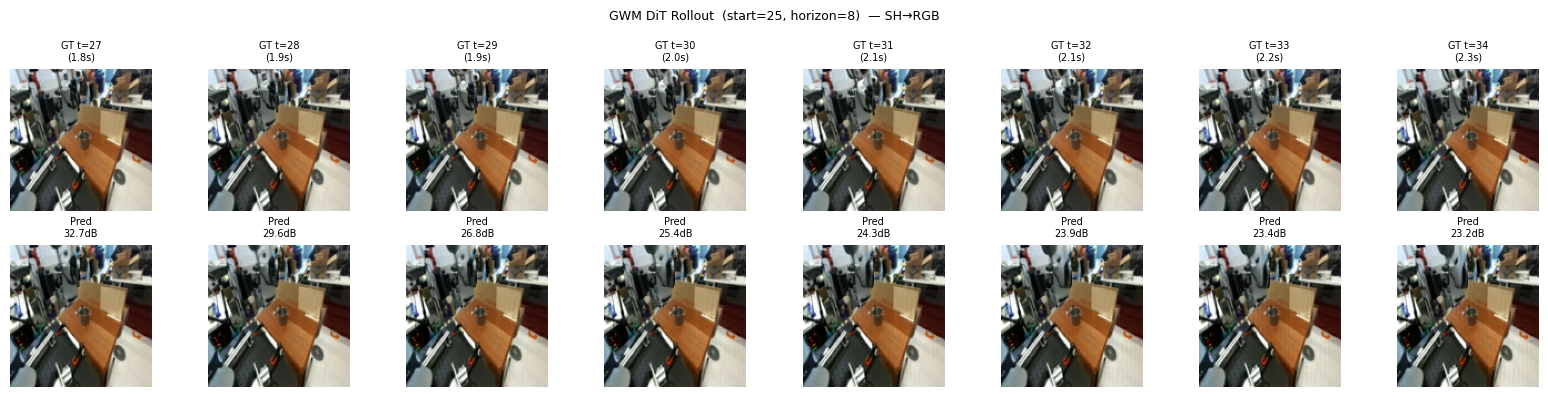

In [10]:
N_COLS   = min(HORIZON, 10)
step     = max(1, HORIZON // N_COLS)
display_steps = list(range(0, HORIZON, step))[:N_COLS]

fig, axes = plt.subplots(2, N_COLS, figsize=(N_COLS * 2, 4))

for col, t in enumerate(display_steps):
    gt_t       = START_FRAME + CONTEXT + t
    pred_gauss = rollout_obs[0, t+1, 14:].clone()
    gt_img     = gt_frame_rgb(obs, gt_t)
    pred_sh    = gauss_to_rgb(pred_gauss)

    axes[0, col].imshow(gt_img)
    axes[0, col].set_title(f"GT t={gt_t}\n({gt_t/15:.1f}s)", fontsize=7)
    axes[0, col].axis("off")

    axes[1, col].imshow(pred_sh)
    axes[1, col].set_title(f"Pred\n{psnrs_sh[t]:.1f}dB", fontsize=7)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("GT",   fontsize=9)
axes[1, 0].set_ylabel("Pred", fontsize=9)
plt.suptitle(f"GWM DiT Rollout  (start={START_FRAME}, horizon={HORIZON})  — SH→RGB", fontsize=9)
plt.tight_layout()
plt.show()

In [11]:
import imageio
from PIL import Image, ImageDraw, ImageFont

GIF_FPS   = 5
GIF_SCALE = 2
OUT_GIF   = "eval_rollout.gif"

frames_gif = []
for t in range(HORIZON):
    gt_t       = START_FRAME + CONTEXT + t
    gt_img     = gt_frame_rgb(obs, gt_t)
    pred_gauss = rollout_obs[0, t+1, 14:].clone()
    pred_sh    = gauss_to_rgb(pred_gauss)

    gt_u8   = (gt_img  * 255).clip(0, 255).astype(np.uint8)
    pred_u8 = (pred_sh * 255).clip(0, 255).astype(np.uint8)

    divider  = np.ones((128, 2, 3), dtype=np.uint8) * 200
    combined = np.concatenate([gt_u8, divider, pred_u8], axis=1)

    img = Image.fromarray(combined).resize(
        (combined.shape[1] * GIF_SCALE, 128 * GIF_SCALE), Image.NEAREST
    )
    draw  = ImageDraw.Draw(img)
    W_sc  = 128 * GIF_SCALE
    draw.rectangle([0,      0, W_sc,       14], fill=(0, 0, 0))
    draw.rectangle([W_sc+2, 0, img.width,  14], fill=(0, 0, 0))
    draw.text((2,        1), f"GT  {gt_t/15:.2f}s",         fill=(255, 255, 255))
    draw.text((W_sc + 4, 1), f"Pred  {psnrs_sh[t]:.1f}dB",  fill=(200, 255, 200))

    frames_gif.append(np.array(img))

imageio.mimsave(OUT_GIF, frames_gif, fps=GIF_FPS, loop=0)
print(f"Saved {OUT_GIF}")

Saved eval_rollout.gif
